In [11]:
!!pip install keras tenserflow

['Requirement already satisfied: keras in /usr/local/lib/python3.12/dist-packages (3.13.2)',
 '\x1bERROR: Could not find a version that satisfies the requirement tenserflow (from versions: none)\x1b\x1b',
 '\x1b\x1bERROR: No matching distribution found for tenserflow\x1b\x1b',
 '\x1b']

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# ── Imports ──
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {tf.keras.__version__}")

TensorFlow version : 2.19.0
Keras version      : 3.13.2


In [15]:
# ── Dataset Paths ──
TRAIN_DIR = "/content/drive/MyDrive/Ai and Machine Learning/Worksheet4/DevanagariHandwrittenDigitDataset/Train"
TEST_DIR  = "/content/drive/MyDrive/Ai and Machine Learning/Worksheet4/DevanagariHandwrittenDigitDataset/Test"

# Image dimensions (consistent shape as instructed)
IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

In [16]:
def load_images_from_folder(folder):
    """
    Loads images and labels from a folder structured as:
        folder/class_name/image_file

    Steps:
        1. Read each class sub-folder (sorted for consistency).
        2. Open each image with PIL, convert to grayscale.
        3. Resize to (IMG_HEIGHT, IMG_WIDTH).
        4. Normalize pixel values to [0, 1].
        5. Append image array and integer label.

    Returns:
        images (np.ndarray): shape (N, 28, 28)
        labels (np.ndarray): shape (N,)  — integer class indices
    """
    images = []
    labels = []

    # Sort class names so label indices are deterministic
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}

    print(f"Found {len(class_names)} classes in '{folder}': {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")                # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))              # resize to 28×28
                img = np.array(img, dtype=np.float32) / 255.0         # normalize → [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  [WARNING] Could not load {img_path}: {e}")

    return np.array(images), np.array(labels)

In [17]:
# ── Load Training and Testing Datasets ──
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)
x_test_raw,  y_test_raw  = load_images_from_folder(TEST_DIR)

print(f"\nRaw training set : {x_train_raw.shape}  |  Labels: {y_train_raw.shape}")
print(f"Raw testing set  : {x_test_raw.shape}   |  Labels: {y_test_raw.shape}")

Found 10 classes in '/content/drive/MyDrive/Ai and Machine Learning/Worksheet4/DevanagariHandwrittenDigitDataset/Train': ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Found 10 classes in '/content/drive/MyDrive/Ai and Machine Learning/Worksheet4/DevanagariHandwrittenDigitDataset/Test': ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

Raw training set : (17000, 28, 28)  |  Labels: (17000,)
Raw testing set  : (3000, 28, 28)   |  Labels: (3000,)


In [18]:
# ── Flatten images for FCN input: (N, 28, 28) → (N, 784) ──
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)   # (N, 784)
x_test  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)   # (N, 784)

# ── One-hot encode labels ──
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"x_train shape : {x_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"x_test  shape : {x_test.shape}")
print(f"y_test  shape : {y_test.shape}")

x_train shape : (17000, 784)
y_train shape : (17000, 10)
x_test  shape : (3000, 784)
y_test  shape : (3000, 10)


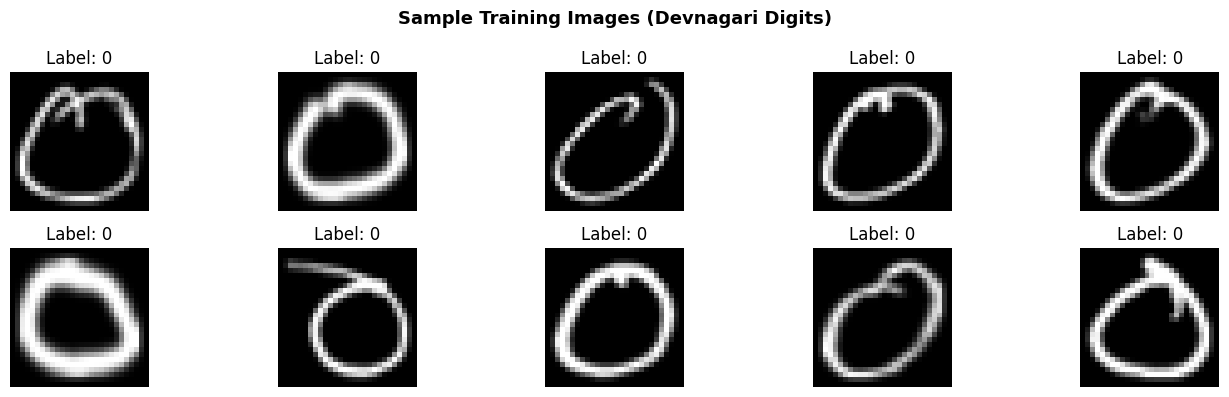

In [19]:
# ── Visualise sample images from the training set ──
plt.figure(figsize=(14, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle("Sample Training Images (Devnagari Digits)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 2: Build the FCN Model

Architecture (Sequential API):
- **Flatten** layer → converts 784-dim input
- **Hidden Layer 1:** 64 neurons, sigmoid activation
- **Hidden Layer 2:** 128 neurons, sigmoid activation
- **Hidden Layer 3:** 256 neurons, sigmoid activation
- **Output Layer:** 10 neurons, softmax activation

In [20]:
# ── Build the Sequential FCN Model ──
model = keras.Sequential(
    [
        keras.layers.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),   # 784-dim input

        # Hidden Layer 1
        keras.layers.Dense(64,  activation='sigmoid', name='hidden_1'),

        # Hidden Layer 2
        keras.layers.Dense(128, activation='sigmoid', name='hidden_2'),

        # Hidden Layer 3
        keras.layers.Dense(256, activation='sigmoid', name='hidden_3'),

        # Output Layer — 10 classes (Devnagari digits 0-9)
        keras.layers.Dense(NUM_CLASSES, activation='softmax', name='output'),
    ],
    name="FCN_Devnagari"
)

# Print model architecture summary
model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3: Compile the Model

- **Optimizer:** Adam
- **Loss Function:** Categorical Crossentropy (since labels are one-hot encoded)
- **Metric:** Accuracy

In [21]:
# ── Compile the Model ──
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"  Optimizer : Adam")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully!
  Optimizer : Adam
  Loss      : categorical_crossentropy
  Metrics   : accuracy


---
## Task 4: Train the Model

- **Batch size:** 128
- **Epochs:** 20
- **Validation split:** 20%
- **Callbacks:** ModelCheckpoint + EarlyStopping

In [22]:
# ── Training Parameters ──
BATCH_SIZE       = 128
EPOCHS           = 20
VALIDATION_SPLIT = 0.2    # 20% of training data used for validation

# ── Callbacks ──
callbacks = [
    # Save the best model (lowest val_loss) during training
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Stop training early if val_loss doesn't improve for 5 consecutive epochs
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

print(f"Training config:")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Max epochs       : {EPOCHS}")
print(f"  Validation split : {int(VALIDATION_SPLIT * 100)}%")

Training config:
  Batch size       : 128
  Max epochs       : 20
  Validation split : 20%


In [23]:
# ── Train the Model ──
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2695 - loss: 2.0478
Epoch 1: val_loss improved from None to 7.07596, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4553 - loss: 1.6728 - val_accuracy: 0.0000e+00 - val_loss: 7.0760
Epoch 2/20
 93/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7976 - loss: 0.6906
Epoch 2: val_loss did not improve from 7.07596
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8415 - loss: 0.5364 - val_accuracy: 0.0000e+00 - val_loss: 8.0937
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9145 - loss: 0.3098
Epoch 3: val_loss did not improve from 7.07596
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9245 - loss: 0.2735 - val_accuracy: 0.0000e+00 - val_loss: 8.7878
Epoch 4/20
 95/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9455 - loss: 0.1967
Epoch 4: val_loss did not improve from 7.0759

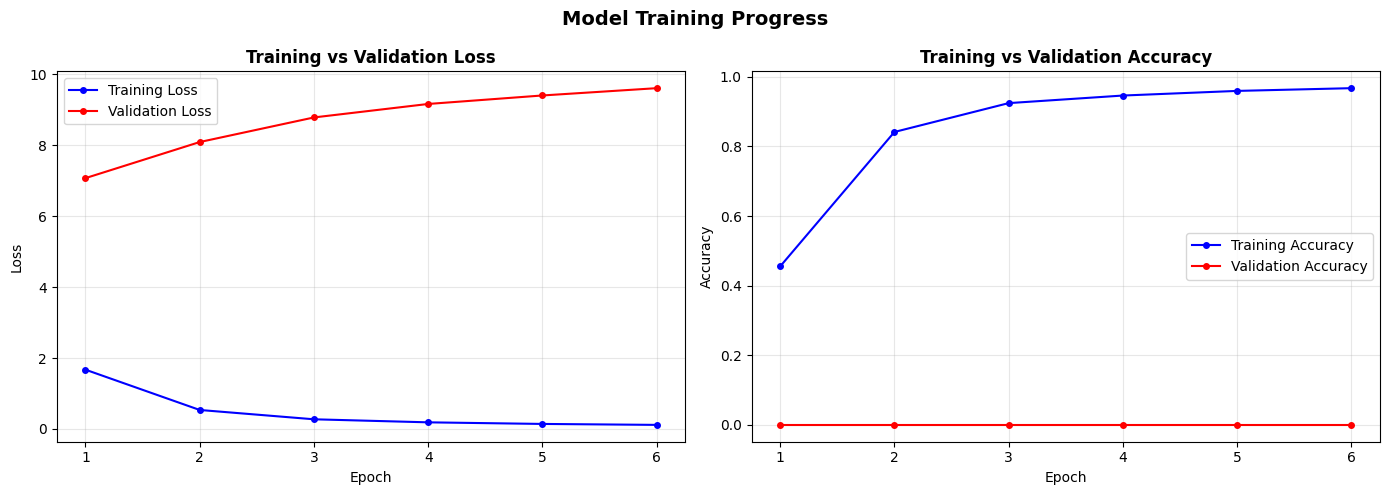

In [24]:
# ── Visualise Training Progress ──
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss, 'b-o', markersize=4, label='Training Loss')
plt.plot(epochs_ran, val_loss,   'r-o', markersize=4, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_acc, 'b-o', markersize=4, label='Training Accuracy')
plt.plot(epochs_ran, val_acc,   'r-o', markersize=4, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Model Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 5: Evaluate the Model

Evaluate the trained model on the **test set** to check final accuracy and loss.

In [25]:
# ── Evaluate on Test Set ──
print("Evaluating model on test set...\n")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)")
print(f"{'='*40}")

Evaluating model on test set...

94/94 - 0s - 1ms/step - accuracy: 0.5907 - loss: 2.1069

  Test Loss     : 2.1069
  Test Accuracy : 0.5907  (59.07%)


---
## Task 6: Save and Load the Model

Save the trained model to a `.h5` file, then reload it and re-evaluate.

In [26]:
# ── Save the Model ──
MODEL_PATH = 'devnagari_fcn_model.h5'
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

Model saved to: devnagari_fcn_model.h5


In [27]:
# ── Load the Saved Model ──
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print(f"Model loaded from: {MODEL_PATH}")
loaded_model.summary()

Model loaded from: devnagari_fcn_model.h5


Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [28]:
# ── Re-evaluate the Loaded Model ──
print("Re-evaluating the loaded model on test set...\n")
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_acc:.4f}  ({loaded_acc * 100:.2f}%)")
print(f"{'='*40}")

Re-evaluating the loaded model on test set...

94/94 - 0s - 5ms/step - accuracy: 0.5907 - loss: 2.1069

  Loaded Model Test Loss     : 2.1069
  Loaded Model Test Accuracy : 0.5907  (59.07%)


---
## Task 7: Making Predictions

Use `model.predict()` on the test set, convert probability outputs to digit labels using `np.argmax()`, and visualise results.

In [29]:
# ── Make Predictions ──
print("Generating predictions on test set...")
predictions = loaded_model.predict(x_test, verbose=0)

# Convert predicted probability distributions to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test,      axis=1)

print(f"Predictions shape : {predictions.shape}")
print(f"\nFirst 10 Predicted Labels : {predicted_labels[:10]}")
print(f"First 10 True Labels      : {true_labels[:10]}")

Generating predictions on test set...
Predictions shape : (3000, 10)

First 10 Predicted Labels : [0 7 0 0 0 7 0 0 0 0]
First 10 True Labels      : [0 0 0 0 0 0 0 0 0 0]


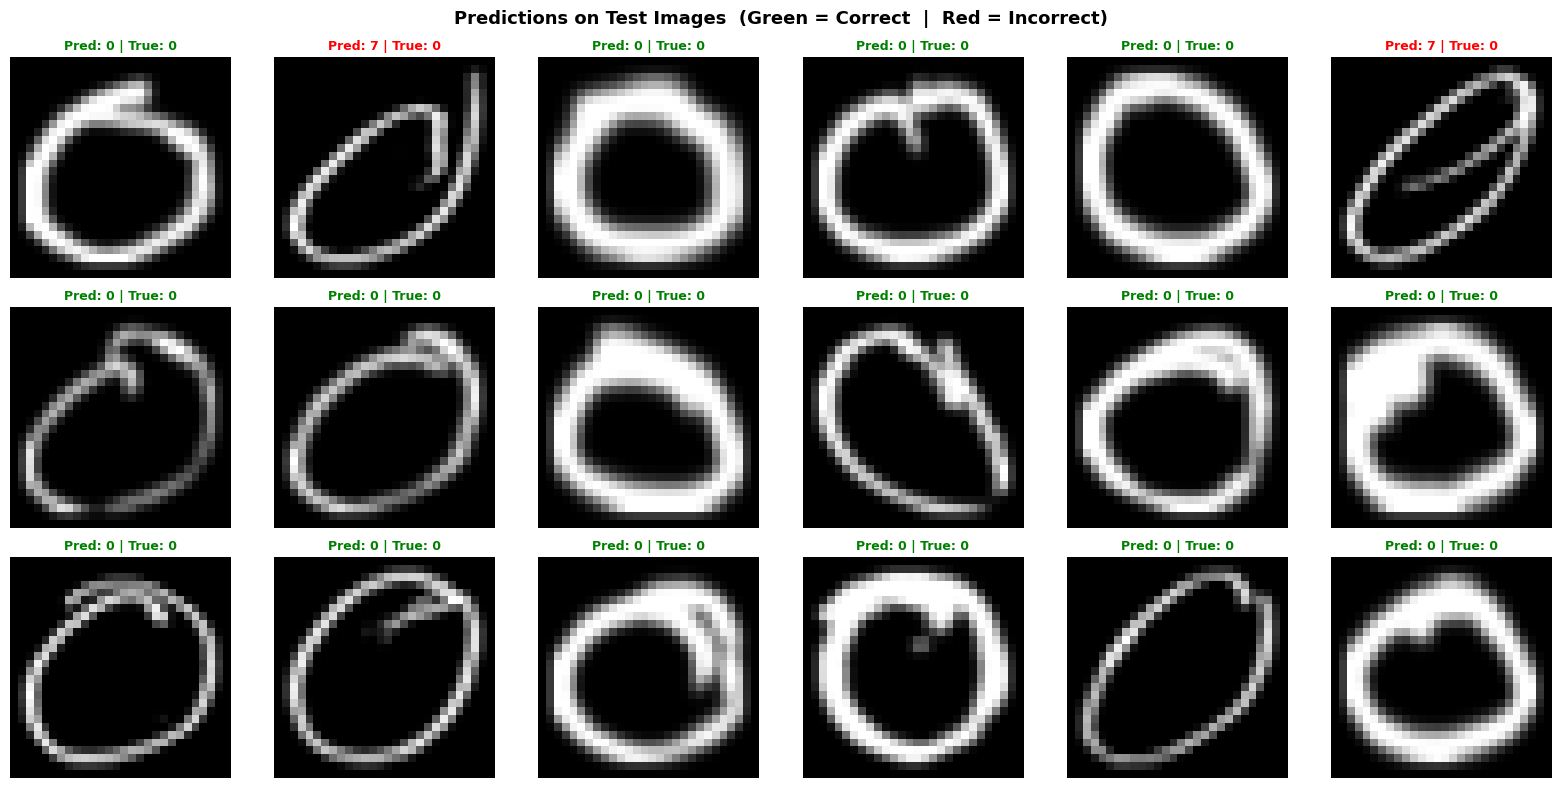

In [30]:
# ── Visualise Predictions — Correct vs Incorrect ──
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()

for i in range(18):
    img   = x_test_raw[i]
    pred  = predicted_labels[i]
    true  = true_labels[i]
    color = 'green' if pred == true else 'red'

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(
        f"Pred: {pred} | True: {true}",
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle(
    'Predictions on Test Images  (Green = Correct  |  Red = Incorrect)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [31]:
# ── Per-class Accuracy Breakdown ──
print("Per-class Accuracy:\n")
print(f"{'Class':<10} {'Correct':>10} {'Total':>10} {'Accuracy':>12}")
print("-" * 46)

for cls in range(NUM_CLASSES):
    mask    = (true_labels == cls)
    correct = np.sum(predicted_labels[mask] == cls)
    total   = np.sum(mask)
    acc     = correct / total if total > 0 else 0
    print(f"digit_{cls:<4}  {correct:>10}  {total:>10}  {acc * 100:>10.2f}%")

print("-" * 46)
overall = np.sum(predicted_labels == true_labels) / len(true_labels)
print(f"{'Overall':<10} {np.sum(predicted_labels == true_labels):>10}  {len(true_labels):>10}  {overall * 100:>10.2f}%")

Per-class Accuracy:

Class         Correct      Total     Accuracy
----------------------------------------------
digit_0            272         300       90.67%
digit_1            291         300       97.00%
digit_2            290         300       96.67%
digit_3              0         300        0.00%
digit_4            292         300       97.33%
digit_5            145         300       48.33%
digit_6            221         300       73.67%
digit_7            261         300       87.00%
digit_8              0         300        0.00%
digit_9              0         300        0.00%
----------------------------------------------
Overall          1772        3000       59.07%


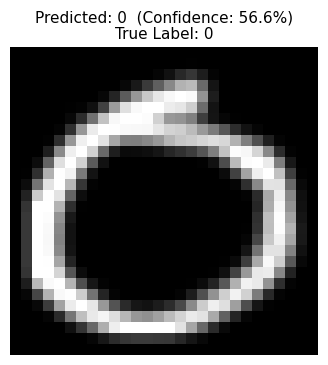

Predicted label : 0
True label      : 0
Confidence      : 56.56%


In [32]:
# ── Single Image Prediction Demo ──
sample_idx = 0
sample_img = x_test[sample_idx].reshape(1, -1)   # shape (1, 784)

single_pred  = loaded_model.predict(sample_img, verbose=0)
pred_label   = np.argmax(single_pred)
true_label   = true_labels[sample_idx]
confidence   = np.max(single_pred) * 100

plt.figure(figsize=(4, 4))
plt.imshow(x_test_raw[sample_idx], cmap='gray')
plt.title(
    f"Predicted: {pred_label}  (Confidence: {confidence:.1f}%)\nTrue Label: {true_label}",
    fontsize=11
)
plt.axis('off')
plt.show()

print(f"Predicted label : {pred_label}")
print(f"True label      : {true_label}")
print(f"Confidence      : {confidence:.2f}%")

---
## Summary

| Task | Description | Status |
|------|-------------|--------|
| Task 1 | Load & Preprocess Devnagari Dataset (PIL) | ✅ |
| Task 2 | Build Sequential FCN (64 → 128 → 256 → 10) | ✅ |
| Task 3 | Compile (Adam, categorical_crossentropy, accuracy) | ✅ |
| Task 4 | Train (batch=128, epochs=20, val_split=0.2, callbacks) | ✅ |
| Task 5 | Evaluate on Test Set | ✅ |
| Task 6 | Save & Reload .h5 Model | ✅ |
| Task 7 | Predictions with np.argmax() + Visualisation | ✅ |

---
*6CS012 Worksheet 4 — Fully Connected Neural Network for Devnagari Digit Classification*